The cumulative reward equation is:

$G_t = \sum_{t'=t}^{T} \gamma^{t'-t} * r_{t'} * t'$.

First, let's not think about the optimal implementation. I will first try to take a brute force approach....

In [1]:
def cumulative_reward_brute(rewards, gamma, t, T):
    G_t = 0  # Initialize cumulative reward
    for t_prime in range(t, T + 1):  # Loop through future time steps t' = t to T
        t_r = rewards[t_prime]  # Reward at time step t'
        G_t += t_r * (gamma ** (t_prime - t)) * t_prime  # Apply the equation
    return G_t

In [2]:
rewards = [0, 1, 2, 3, 4, 5]
gamma = 0.9
t = 1
T = 4
G_t = cumulative_reward_brute(rewards, gamma, t, T)
print(G_t)

23.554000000000002


Now that I have the understanding of the mechanics of the equation, I will try to optimize the performance using NumPy

In [3]:
import numpy as np

In [4]:
def cumulative_reward_vectorized(rewards, gamma, t, T):
    # Create a range of time steps t' from t to T
    t_prime = np.arange(t, T + 1)

    # Extract the rewards from t to T
    rewards_t_prime = rewards[t:T + 1]

    # Compute the discount factor raised to (t' - t)
    gamma_factors = gamma ** (t_prime - t)

    # Compute the cumulative reward using vectorized operations
    G_t = np.sum(rewards_t_prime * gamma_factors * t_prime)
    return G_t

In [5]:
rewards = np.array([0, 1, 2, 3, 4, 5])
gamma = 0.9
t = 1
T = 5
G_t = cumulative_reward_vectorized(rewards, gamma, t, T)
print(G_t)

39.956500000000005


In [6]:
cumulative_reward_brute([0, 1, 2, 3, 4, 5], gamma, 1, 5) == cumulative_reward_vectorized(np.array([0, 1, 2, 3, 4, 5]), gamma, 1, 5)

True

$
Q(s, a) = R(s, a) + \gamma \sum_{s'} P(s' | s, a) V(s')
$

This is the Bellman equation, which can be implemented in Python as follows

In [7]:
def calculate_Q_value_brute(num_states, rewards, transition_prob, gamma, V_states, state, action):
    # Step 1: Get the reward for taking action 'a' in state 's'
    reward = rewards[state][action]
    
    # Step 2: Compute the expected future value (sum of discounted future rewards)
    q_sa = reward
    for next_state in range(num_states):
        # P(s' | s, a) is the probability of transitioning to next_state from current state and action
        transition_prob_s_a_next = transition_prob[state][action][next_state]
        # Add discounted future value
        q_sa += gamma * transition_prob_s_a_next * V_states[next_state]
    
    return q_sa

In [8]:
rewards = [[1, 0], [0, 1], [-1, 0]]
transition_prob = [
    # State 0
    [[0.5, 0.5, 0], [0, 1, 0]],  # Probabilities for actions in state 0
    # State 1
    [[0.7, 0.2, 0.1], [0, 0, 1]], # Probabilities for actions in state 1
    # State 2
    [[0.4, 0.6, 0], [0, 0, 1]]   # Probabilities for actions in state 2
]
V_states = [1, 0.5, -0.5]
gamma = 0.9
state = 0
action = 0
num_states = 3

calculate_Q_value_brute(num_states, rewards, transition_prob, gamma, V_states, state, action)

1.675

In [9]:
def calculate_Q_value_vectorized(num_states, rewards, transition_prob, gamma, V_states, state, action):
    # Step 1: Get the reward for taking action 'a' in state 's'
    reward = rewards[state][action]

    # Step 2: Compute the expected future value (sum of discounted future rewards)
    # Vectorized operation to calculate Q(s, a)
    
    # Extract the transition probabilities for the current state and action
    transition_probs = transition_prob[state][action]
    
    # Compute the sum of discounted future state values using vectorized multiplication
    expected_future_value = np.dot(transition_probs, V_states)
    
    # Compute the final Q-value
    q_sa = reward + gamma * expected_future_value

    return q_sa

In [10]:
rewards = np.array([[1, 0], [0, 1], [-1, 0]])
transition_prob = np.array([
    # State 0
    [[0.5, 0.5, 0], [0, 1, 0]],  # Probabilities for actions in state 0
    # State 1
    [[0.7, 0.2, 0.1], [0, 0, 1]], # Probabilities for actions in state 1
    # State 2
    [[0.4, 0.6, 0], [0, 0, 1]]   # Probabilities for actions in state 2
])
V_states = [1, 0.5, -0.5]
gamma = 0.9
state = 0
action = 0
num_states = 3

calculate_Q_value_vectorized(num_states, rewards, transition_prob, gamma, V_states, state, action)

1.675

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

In [12]:
# ******Reading CSV files (Start)******
df1 = pd.read_csv("data/samples-001.csv")
df2 = pd.read_csv("data/samples-002.csv")
df3 = pd.read_csv("data/samples-003.csv")
# ******Reading CSV files (End)******

In [13]:
y1 = df1.iloc[:, 1].values
y2 = df2.iloc[:, 1].values
y3 = df3.iloc[:, 1].values
x = range(len(y1))

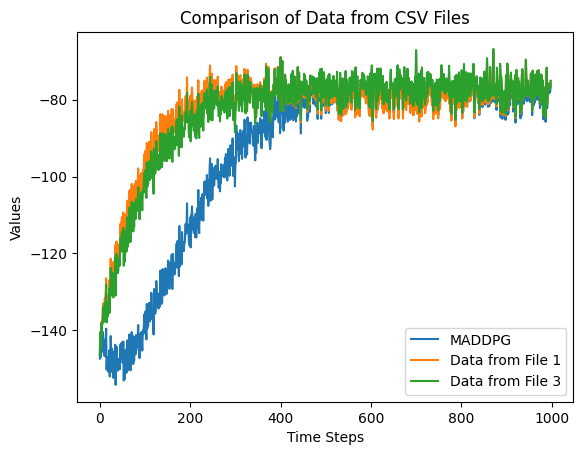

In [15]:
# ******Plot line chart (Start)*****
plt.plot(x, y2, label="MADDPG")
plt.plot(x, y1, label="Data from File 1")
plt.plot(x, y3, label="Data from File 3")

# Add labels, title, and legend
plt.xlabel("Time Steps")
plt.ylabel("Values")
plt.title("Comparison of Data from CSV Files")
plt.legend()

# Display the plot
plt.show()
# ******Plot line chart (End)******